In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [29]:
files=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260827_133310_0.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260827_133310_1.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260827_133310_2.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260827_133310_3.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260827_133310_4.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260827_133310_5.csv'

]

In [30]:
df=pd.DataFrame()
for file in files:
    temp_df=pd.read_csv(file)
    df=pd.concat([df,temp_df], ignore_index=True)

In [31]:
df

,m_planet,time,a
0,0.030027,99000.0,0.473645
1,0.030027,99000.0,-8024.874066
2,0.030027,99000.0,0.479678
3,0.030027,99000.0,-918.383433
4,0.030027,99000.0,-567.039943
...,...,...,...
794,0.000300,2297000.0,0.977760
795,0.000300,2297000.0,1.005259
796,0.000300,2297000.0,1.018470
797,0.000300,2297000.0,0.664488


In [32]:
proportion = df.groupby("m_planet")["a"].apply(lambda x: (x < 0).mean())

In [33]:
proportion

m_planet
0.000300    0.021858
0.000712    0.082759
0.001689    0.283582
0.004004    0.440559
0.009496    0.682540
0.030027    0.529412
Name: a, dtype: float64

In [39]:
ejection_df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260827_133310_ejection_results.txt', header=None)

In [40]:
ejection_df.columns=['mass','time','result']

In [41]:
ejection_df

,mass,time,result
0,0.030027,0.0,Captured
1,0.030027,0.0,Captured
2,0.030027,0.0,Captured
3,0.030027,0.0,Captured
4,0.030027,0.0,Captured
...,...,...,...
3996,0.000300,2028000.0,Ejected
3997,0.000300,2037000.0,Ejected
3998,0.000300,2186000.0,Ejected
3999,0.000300,2239000.0,Ejected


In [55]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [56]:
ejection_df

,mass,time,result
0,0.030027,0.0,Captured
1,0.030027,0.0,Captured
2,0.030027,0.0,Captured
3,0.030027,0.0,Captured
4,0.030027,0.0,Captured
...,...,...,...
3996,0.000300,2028000.0,Ejected
3997,0.000300,2037000.0,Ejected
3998,0.000300,2186000.0,Ejected
3999,0.000300,2239000.0,Ejected


In [287]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260906_172814_ejection_results.txt', header=None)

In [288]:
df.columns=['mass','time','result']

In [289]:
df

,mass,time,result
0,0.030027,0.000000e+00,Captured
1,0.030027,0.000000e+00,Captured
2,0.030027,0.000000e+00,Captured
3,0.030027,0.000000e+00,Captured
4,0.030027,0.000000e+00,Captured
...,...,...,...
4142,0.000300,7.819036e+06,Ejected
4143,0.000300,7.902162e+06,Ejected
4144,0.000300,7.938529e+06,Ejected
4145,0.000300,8.099586e+06,Ejected


In [290]:
ejection_df, capture_df=compute_cumulative_outcome_fractions(df, df.mass.unique(),[800,800,800,800,800,800])

In [291]:
ejection_df

,0.000000e+00,5.195372e+03,1.558612e+04,2.047942e+04,2.559927e+04,3.071912e+04,3.102994e+04,3.583898e+04,3.620160e+04,4.095883e+04,...,7.242349e+06,7.263131e+06,7.367038e+06,7.377429e+06,7.715128e+06,7.819036e+06,7.902162e+06,7.938529e+06,8.099586e+06,8.182712e+06
0.030027,0.0,0.0,0.0,0.02125,0.10375,0.27,0.2700,0.3950,0.395,0.48,...,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500,0.91500
0.009496,0.0,0.0,0.0,0.00000,0.00000,0.00,0.0075,0.0075,0.040,0.04,...,0.90250,0.90250,0.90250,0.90250,0.90250,0.90250,0.90250,0.90250,0.90250,0.90250
0.004004,0.0,0.0,0.0,0.00000,0.00000,0.00,0.0000,0.0000,0.000,0.00,...,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000,0.86000
0.001689,0.0,0.0,0.0,0.00000,0.00000,0.00,0.0000,0.0000,0.000,0.00,...,0.85625,0.85625,0.85625,0.85625,0.85625,0.85625,0.85625,0.85625,0.85625,0.85625
0.000712,0.0,0.0,0.0,0.00000,0.00000,0.00,0.0000,0.0000,0.000,0.00,...,0.81875,0.81875,0.81875,0.81875,0.81875,0.81875,0.81875,0.81875,0.81875,0.81875
0.000300,0.0,0.0,0.0,0.00000,0.00000,0.00,0.0000,0.0000,0.000,0.00,...,0.76625,0.76750,0.76875,0.77000,0.77125,0.77250,0.77375,0.77500,0.77625,0.77750


In [292]:
files=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260906_172814_0.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260906_172814_1.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260906_172814_2.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260906_172814_3.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260906_172814_4.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260906_172814_5.csv'
]

In [293]:
df=pd.DataFrame()
for file in files:
    temp_df=pd.read_csv(file)
    df=pd.concat([df,temp_df], ignore_index=True)

In [294]:
df

,m_planet,time,a,e
0,0.030027,2.406331e+05,1.6144281684904105,0.095656
1,0.030027,2.406331e+05,1.5933337531369547,0.153261
2,0.030027,2.406331e+05,1.7810812550761723,0.183300
3,0.030027,2.406280e+05,Unbound,6.521489
4,0.030027,2.406331e+05,1.4868957499661282,0.210788
...,...,...,...,...
648,0.000300,8.322987e+06,3.0222442981794466,0.004863
649,0.000300,8.322987e+06,3.0023148455666133,0.013830
650,0.000300,8.322987e+06,133849.35865959525,0.999994
651,0.000300,8.322982e+06,Unbound,1.000172


In [183]:
mask = df["a"] != 'Unbound'
df_bound = df[mask]

In [192]:
df_bound['a']=df_bound['a'].astype('float')

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_68922/1791789238.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bound['a']=df_bound['a'].astype('float')


(array([  1.,   1.,   7.,  10.,   9.,   1.,   1.,   0.,   2.,   2.,   0.,
          3.,   4.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,  17.,
        102., 134., 115.,  70.,  16.,   1.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   1.]),
 array([0.45593406, 0.47875532, 0.50157658, 0.52439784, 0.5472191 ,
        0.57004036, 0.59286162, 0.61568288, 0.63850414, 0.6613254 ,
        0.68414666, 0.70696792, 0.72978918, 0.75261044, 0.7754317 ,
        0.79825296, 0.82107422, 0.84389548, 0.86671674, 0.889538  ,
        0.91235926, 0.93518052, 0.95800178, 0.98082304, 1.0036443 ,
        1.02646556, 1.04928682, 1.07210808, 1.09492934, 1.1177506 ,
        1.14057186, 1.16339312, 1.18621438, 1.20903564, 1.2318569 ,
        1.25467816, 1.27749942, 1.30032068, 1.

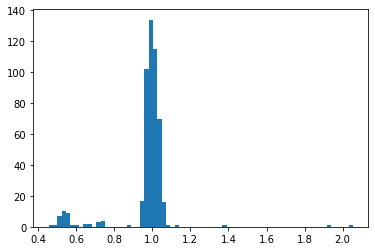

In [204]:
plt.hist(df_bound[df_bound.a<10].a, bins=70)

In [205]:
df_bound['energy']=1/df_bound['a']

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_68922/764781930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bound['energy']=1/df_bound['a']


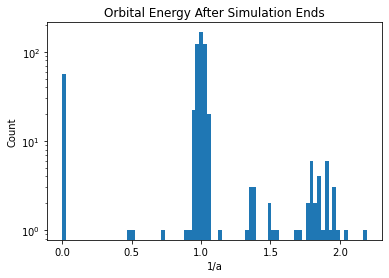

In [214]:
plt.hist(df_bound.energy, bins=80)
plt.title('Orbital Energy After Simulation Ends')
plt.ylabel('Count')
plt.xlabel('1/a')
plt.yscale('log')
plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/orbital_energy_hist.png',bbox_inches='tight',facecolor='white')

In [ ]:
df_boun

,m_planet,time,a,e
0,0.030027,99000.0,0.537875,0.095240
2,0.030027,99000.0,0.541946,0.090563
3,0.030027,99000.0,64528.515673,0.809003
7,0.030027,99000.0,0.596960,0.153922
8,0.030027,99000.0,0.509833,0.174738
...,...,...,...,...
794,0.000300,2297000.0,0.978103,0.013310
795,0.000300,2297000.0,1.005516,0.023849
796,0.000300,2297000.0,1.017810,0.005149
797,0.000300,2297000.0,0.664819,0.325487


In [202]:
len(df_bound[df_bound.a<10].a)

501

In [199]:
df_bound.a.median()

1.0015075885782971

In [270]:
ejection_df

,0.000000e+00,6.231688e+04,6.294740e+04,9.347532e+04,9.442110e+04,9.467896e+04,1.262386e+05,1.577983e+05,2.211728e+05,2.527689e+05,...,3.541219e+06,3.572837e+06,3.604455e+06,3.667691e+06,3.730928e+06,3.794164e+06,3.825782e+06,3.857400e+06,3.889018e+06,3.952254e+06
0.030027,0.0,0.34375,0.34375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,...,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375
0.009496,0.0,0.00000,0.01000,0.01000,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,...,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375
0.004004,0.0,0.00000,0.00000,0.00000,0.00000,0.00375,0.03000,0.10000,0.10000,0.10000,...,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000
0.001689,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01000,0.02125,...,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750
0.000712,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750
0.000300,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.04250,0.04500,0.04625,0.04750,0.05000,0.05125,0.05375,0.05500,0.05750,0.06000


In [271]:
ejection_df.columns[-1]

3952253.748130236

In [298]:
ejection_df.columns[-1]

8182711.646557326

In [299]:
left_counts = ejection_df[8182711.646557326]*800

unbound_counts = (
    df.groupby("m_planet")["a"]
    .apply(lambda x: (x == "Unbound").sum())
)

total_affected = left_counts.add(unbound_counts, fill_value=0)

In [300]:
total_affected

0.000300    627.0
0.000712    662.0
0.001689    691.0
0.004004    704.0
0.009496    749.0
0.030027    750.0
dtype: float64

(0.0, 200000.0)

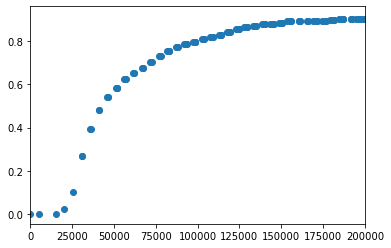

In [303]:
plt.scatter( ejection_df.columns,ejection_df.loc[0.030027	])
plt.xlim(0,0.2e6)

In [279]:
ejection_df

,0.000000e+00,6.231688e+04,6.294740e+04,9.347532e+04,9.442110e+04,9.467896e+04,1.262386e+05,1.577983e+05,2.211728e+05,2.527689e+05,...,3.541219e+06,3.572837e+06,3.604455e+06,3.667691e+06,3.730928e+06,3.794164e+06,3.825782e+06,3.857400e+06,3.889018e+06,3.952254e+06
0.030027,0.0,0.34375,0.34375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,...,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375,0.60375
0.009496,0.0,0.00000,0.01000,0.01000,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,...,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375,0.16375
0.004004,0.0,0.00000,0.00000,0.00000,0.00000,0.00375,0.03000,0.10000,0.10000,0.10000,...,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000,0.10000
0.001689,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01000,0.02125,...,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750,0.10750
0.000712,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750,0.03750
0.000300,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.04250,0.04500,0.04625,0.04750,0.05000,0.05125,0.05375,0.05500,0.05750,0.06000


In [274]:
ejection_df.index

Index([0.030027, 0.0094955, 0.00400422, 0.00168856, 0.00071206, 0.00030027], dtype='float64')

In [51]:
total_affected.index

Index([0.00030027, 0.00071206, 0.00168856, 0.00400422, 0.0094955, 0.030027], dtype='float64', name='mass')

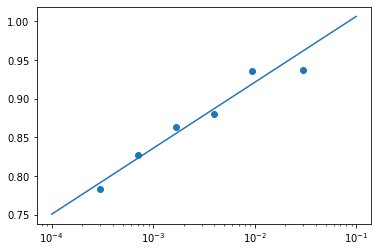

In [308]:
plt.scatter(total_affected.index,total_affected/800)
plt.xscale('log')
x=np.logspace(-4,-1)
y=e_frac_vs_mass(x)
plt.plot(x,y)

Text(0.5, 0, 'Planet Mass (M*)')

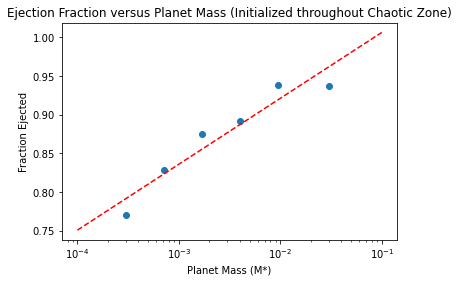

In [216]:
plt.scatter(total_affected.index,total_affected.values/800)
plt.xscale('log')

x=np.logspace(-4,-1)
y=e_frac_vs_mass(x)
plt.plot(x,y,'red',linestyle='--')
plt.title(r'Ejection Fraction versus Planet Mass (Initialized throughout Chaotic Zone)')
plt.ylabel('Fraction Ejected')
plt.xlabel('Planet Mass (M*)')
#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/frac_vs_mass_fit.png', facecolor='white',bbox_inches='tight')

In [65]:
def log_fit(q, a, b):
    return a * np.log10(q) + b

In [84]:
popt, pcov = curve_fit(log_fit, total_affected.index,total_affected.values/800)

In [85]:
a, b = popt

In [86]:
print(a,b)

0.08509622694638502 1.0913245932397357


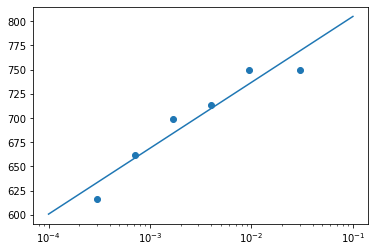

In [73]:
x=np.logspace(-4,-1,20)
plt.plot(x,log_fit(x,a,b))
plt.scatter(total_affected.index,total_affected.values)

plt.xscale('log')

In [306]:
def e_frac_vs_mass(q):
    a=0.08509622694638502
    b=1.0913245932397357
    return a * np.log10(q) + b
def imf(Mstar):
    """Salpeter IMF, arbitrary normalization."""
    
    return 1000*Mstar**(-2.35)
def available_mass(M_star):
    """Moro_Martin 2018 Section 3.2.1"""
    return 1e-4*M_star

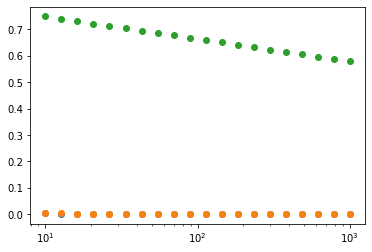

In [88]:
x=np.logspace(1,3,20)
plt.scatter(x,e_frac_vs_mass(0.000954588/x)*imf(x))
plt.scatter(x,imf(x))
plt.scatter(x,e_frac_vs_mass(0.000954588/x))


plt.xscale('log')

In [82]:
0.000954588/x

array([9.54588000e-05, 7.49122451e-05, 5.87881312e-05, 4.61345721e-05,
       3.62045654e-05, 2.84118937e-05, 2.22965169e-05, 1.74974139e-05,
       1.37312700e-05, 1.07757511e-05, 8.45637808e-06, 6.63622701e-06,
       5.20784531e-06, 4.08690853e-06, 3.20724222e-06, 2.51691531e-06,
       1.97517438e-06, 1.55003779e-06, 1.21640761e-06, 9.54588000e-07])

In [126]:
masses = np.logspace(
    np.log10(0.08),
    np.log10(100),
    10000)
def integrated_ejection_mass(masses, e_frac=e_frac_vs_mass, imf=imf, planet_mass=0.000954588):
    weights=imf(masses)
    fractions=e_frac(planet_mass/masses)
    disc_mass=available_mass(masses)

    average_ejected_mass = np.trapz(weights * fractions * disc_mass, x=masses)/ np.trapz(weights, x=masses)
    return average_ejected_mass
       
    
    

In [129]:
integrated_ejection_mass(masses, planet_mass=3.00274e-6)*0.08*333030

0.477385895786155

In [250]:

# Stellar number densities [stars / pc^3]
stellar_densities = np.array([
    0.08,
    6.0,
    326
])

# Planet masses [M_sun]
planet_masses = np.array([
    3.003e-6,      # Earth
    9.54588e-4,    # Jupiter
])

# Labels for table
planet_labels = [
    r"1 M_Earth",
    r"1 M_Jupiter"
]

table = pd.DataFrame(
    index=stellar_densities,
    columns=planet_labels,
    dtype=float
)

for density in stellar_densities:
    for planet_mass, label in zip(planet_masses, planet_labels):

        mass_per_star = integrated_ejection_mass(
            masses,
            planet_mass=planet_mass
        )

        table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"

table.index.name = "Stellar Density [stars / pc^3]"

table

/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_68922/1856443419.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.4774' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"
/var/folders/vk/2xktddx11s99wx6wl7rlmm9c0000gn/T/ipykernel_68922/1856443419.py:34: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6380' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.loc[density, label] = f"{density * mass_per_star * 333030:.4f}"


,1 M_Earth,1 M_Jupiter
Stellar Density [stars / pc^3],,
0.08,0.4774,0.6380
6.00,35.8041,47.8517
326.00,1945.3574,2599.9447


In [251]:
row_labels=[
    r'0.08 pc$^{-3}$ (Solar Neigborhood)',
    r'6.0 pc$^{-3}$(L1495)',
    r'326 pc$^{-3}$(IC 348)'
]

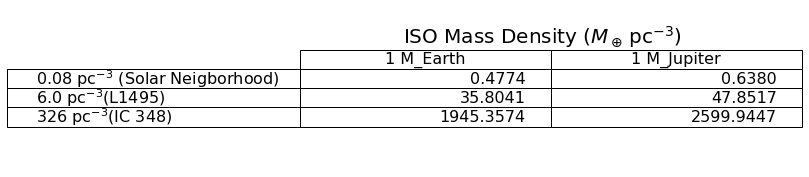

In [ ]:
fig, ax = plt.subplots(figsize=(9,3))

ax.axis("off")

plt_table = ax.table(
    cellText=table.values,
    rowLabels=row_labels,
    colLabels=table.columns,
    loc="center"
)
plt_table.set_fontsize(16)
plt_table.scale(1.0, 1.6)
# ax.set_title(
#     r"ISO Mass Density ($M_\oplus\,\mathrm{pc}^{-3}$)",
#     fontsize=20
# )
fig.suptitle(
    r"ISO Mass Density ($M_\oplus\,\mathrm{pc}^{-3}$)",
    fontsize=20,
    y=0.80
)
#plt.title(r'ISO density (pc$^{-3}$) as a function of stellar density')
#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/iso_density_table', facecolor='white', bbox_inches='tight')

In [54]:
captured_df

NameError: name 'captured_df' is not defined

In [22]:
bound_a=df[df.a>0]

In [23]:
bound_a

,m_planet,time,a
0,0.030027,99000.0,0.591978
3,0.030027,99000.0,0.536830
6,0.030027,99000.0,0.589655
9,0.030027,99000.0,0.575770
10,0.030027,99001.0,0.577312
...,...,...,...
429,0.000300,2349000.0,27927.588988
430,0.000300,2349000.0,19626.053647
431,0.000300,2349000.0,47287.212370
433,0.000300,2349000.0,50.702160


(0.0, 10.0)

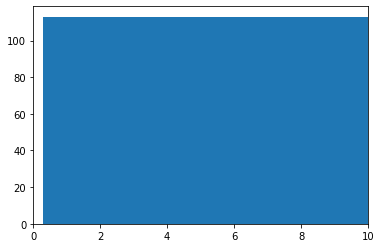

In [27]:
plt.hist(bound_a.a, bins=200)
plt.xlim(0,10)

In [28]:
for a in bound_a.a:
    print(a)

0.5919781076550651
0.5368295100491814
0.5896553150004614
0.5757704461397356
0.5773118918355491
0.5182149957131337
0.5054445318695072
0.5581341127189668
0.5415912596141841
0.5638669075461162
0.5500397033562993
0.4648718052196379
0.5728231317830091
0.5430009929620733
0.5249210763418354
0.5376393184911328
0.5449932608979314
0.5829400345442974
0.5345661742326414
0.5267486285617544
0.4839698033604784
0.5760325083766806
0.5267010007023827
0.449087219283197
0.5930351494253477
0.5989499717813346
0.6439016751915181
0.5278528649380771
0.5627217590329658
0.5013901295040301
0.4521231055626582
2430.459629417207
3392.3817267878753
0.6476706204790328
0.5471449434714187
0.4153695451182003
0.5707830097909529
0.5155200766320729
0.3023967607612272
0.5514608902508128
0.5769804181840189
0.4884678809464551
0.5229568397333456
0.5178541137881649
0.6001016560578726
0.534501422677887
0.4599583311704014
0.5118041126226989
0.5411191697079606
0.5301030315755325
0.6665281777243682
0.5843937004893497
0.6314717004269